# Euro Coin Classification

This notebook analyzes a dataset of Euro coin images and develops machine learning models for automatic coin recognition.

The dataset contains eight classes corresponding to 1, 2, 5, 10, 20, and 50 cents, as well as 1 and 2 Euro coins.

In [85]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_DIR = PROJECT_DIR / "data"
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

print("Project directory:", PROJECT_DIR)
print("Data directory exists:", DATA_DIR.exists())
print("Train directory exists:", TRAIN_DIR.exists())
print("Test directory exists:", TEST_DIR.exists())

Project directory: d:\UNIPV\Year 2\Machine Learning\euro-coin-classification
Data directory exists: True
Train directory exists: True
Test directory exists: True


## 1. Dataset Configuration

The coin classes are represented by their monetary values in cents. The dataset contains eight distinct classes.

In [86]:
# Coin classes and their real face values in cents
CLASS_NAMES = ["001", "002", "005", "010", "020", "050", "100", "200"]

COIN_VALUES = {
    "001": 1,
    "002": 2,
    "005": 5,
    "010": 10,
    "020": 20,
    "050": 50,
    "100": 100,
    "200": 200,
}

COIN_LABELS = {
    "001": "1 cent",
    "002": "2 cents",
    "005": "5 cents",
    "010": "10 cents",
    "020": "20 cents",
    "050": "50 cents",
    "100": "1 euro",
    "200": "2 euros",
}

print("Number of classes:", len(CLASS_NAMES))
print("Classes:", CLASS_NAMES)

Number of classes: 8
Classes: ['001', '002', '005', '010', '020', '050', '100', '200']


## 2. Dataset Size and Class Distribution

The number of training and test images is counted for each coin class to verify whether the dataset is balanced.

In [87]:
def count_images_by_class(directory):
    counts = {}

    for class_name in CLASS_NAMES:
        class_directory = directory / class_name

        if not class_directory.exists():
            raise FileNotFoundError(
                f"Class directory not found: {class_directory}"
            )

        image_files = list(class_directory.glob("*.png"))
        counts[class_name] = len(image_files)

    return counts


train_counts = count_images_by_class(TRAIN_DIR)
test_counts = count_images_by_class(TEST_DIR)

counts_df = pd.DataFrame({
    "class_code": CLASS_NAMES,
    "coin_label": [COIN_LABELS[name] for name in CLASS_NAMES],
    "coin_value_cents": [COIN_VALUES[name] for name in CLASS_NAMES],
    "train_images": [train_counts[name] for name in CLASS_NAMES],
    "test_images": [test_counts[name] for name in CLASS_NAMES],
})

counts_df

,class_code,coin_label,coin_value_cents,train_images,test_images
0,001,1 cent,1,100,20
1,002,2 cents,2,100,20
2,005,5 cents,5,100,20
3,010,10 cents,10,100,20
4,020,20 cents,20,100,20
5,050,50 cents,50,100,20
6,100,1 euro,100,100,20
7,200,2 euros,200,100,20


### Class Balance

Each class contains the same number of training and test images. Therefore, the dataset is balanced and does not require class weighting based on sample frequency.

In [88]:
total_train_images = counts_df["train_images"].sum()
total_test_images = counts_df["test_images"].sum()
total_images = total_train_images + total_test_images

print("Total training images:", total_train_images)
print("Total test images:", total_test_images)
print("Total dataset images:", total_images)

Total training images: 800
Total test images: 160
Total dataset images: 960


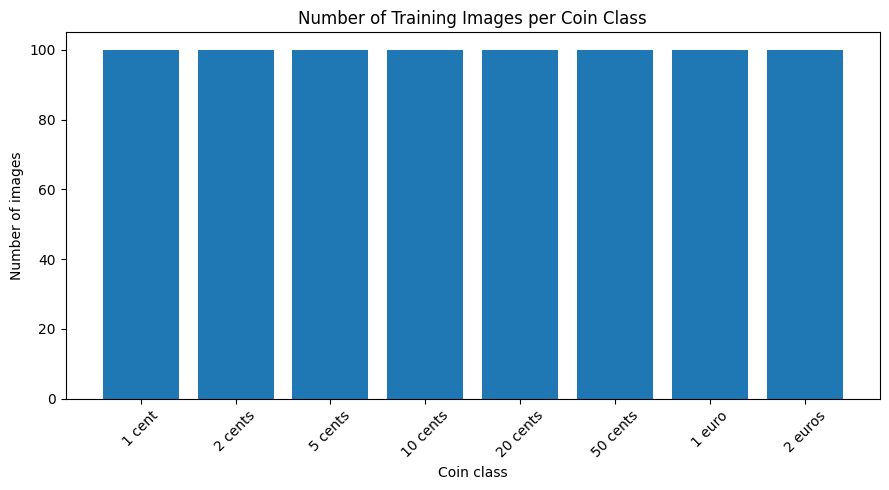

In [89]:
plt.figure(figsize=(9, 5))

plt.bar(
    counts_df["coin_label"],
    counts_df["train_images"]
)

plt.title("Number of Training Images per Coin Class")
plt.xlabel("Coin class")
plt.ylabel("Number of images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Visual Inspection of the Dataset

One image from each class is displayed to inspect the visual appearance of the coins.

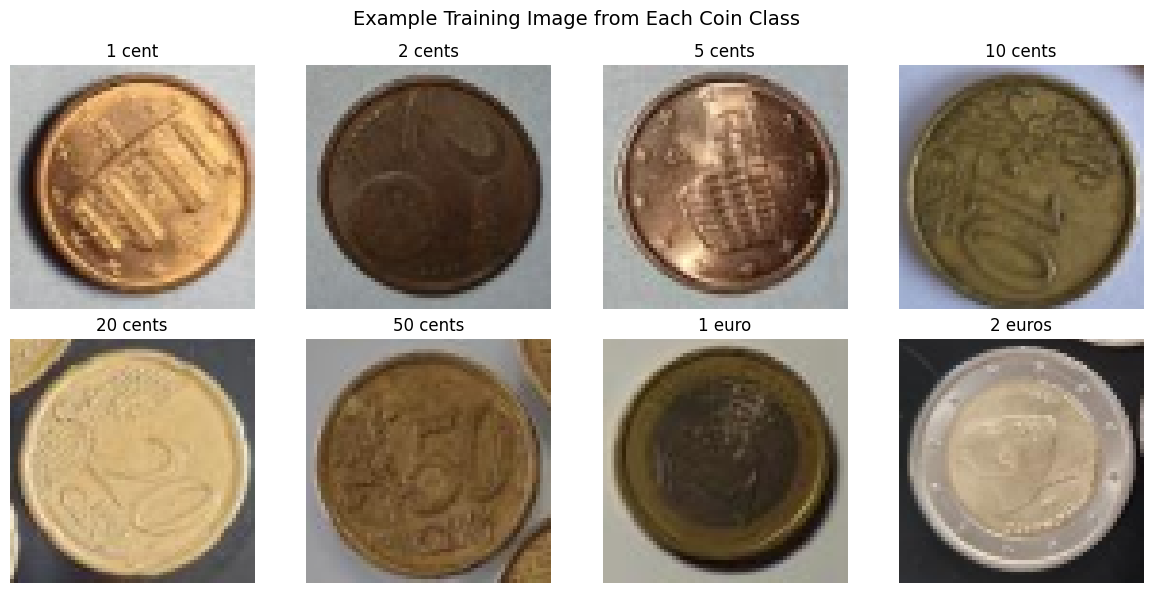

In [90]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for index, class_name in enumerate(CLASS_NAMES):
    image_paths = sorted((TRAIN_DIR / class_name).glob("*.png"))

    if not image_paths:
        raise FileNotFoundError(
            f"No PNG images found in: {TRAIN_DIR / class_name}"
        )

    image = Image.open(image_paths[0]).convert("RGB")

    axes[index].imshow(image)
    axes[index].set_title(COIN_LABELS[class_name])
    axes[index].axis("off")

plt.suptitle("Example Training Image from Each Coin Class", fontsize=14)
plt.tight_layout()
plt.show()

### Initial Observations

The images show considerable variation in illumination, background, sharpness, orientation, and coin side. Some classes also have similar colors and shapes, which may make classification difficult. Rotation-invariant features or data augmentation may therefore be useful.

In [91]:
sample_path = sorted((TRAIN_DIR / CLASS_NAMES[0]).glob("*.png"))[0]

with Image.open(sample_path) as sample_image:
    print("Sample image path:", sample_path)
    print("Image size:", sample_image.size)
    print("Image mode:", sample_image.mode)
    print("Image format:", sample_image.format)

Sample image path: d:\UNIPV\Year 2\Machine Learning\euro-coin-classification\data\train\001\001-001.png
Image size: (64, 64)
Image mode: RGB
Image format: PNG


## 4. Intra-Class Variability

Several samples from each class are displayed to investigate variations within the same coin category.

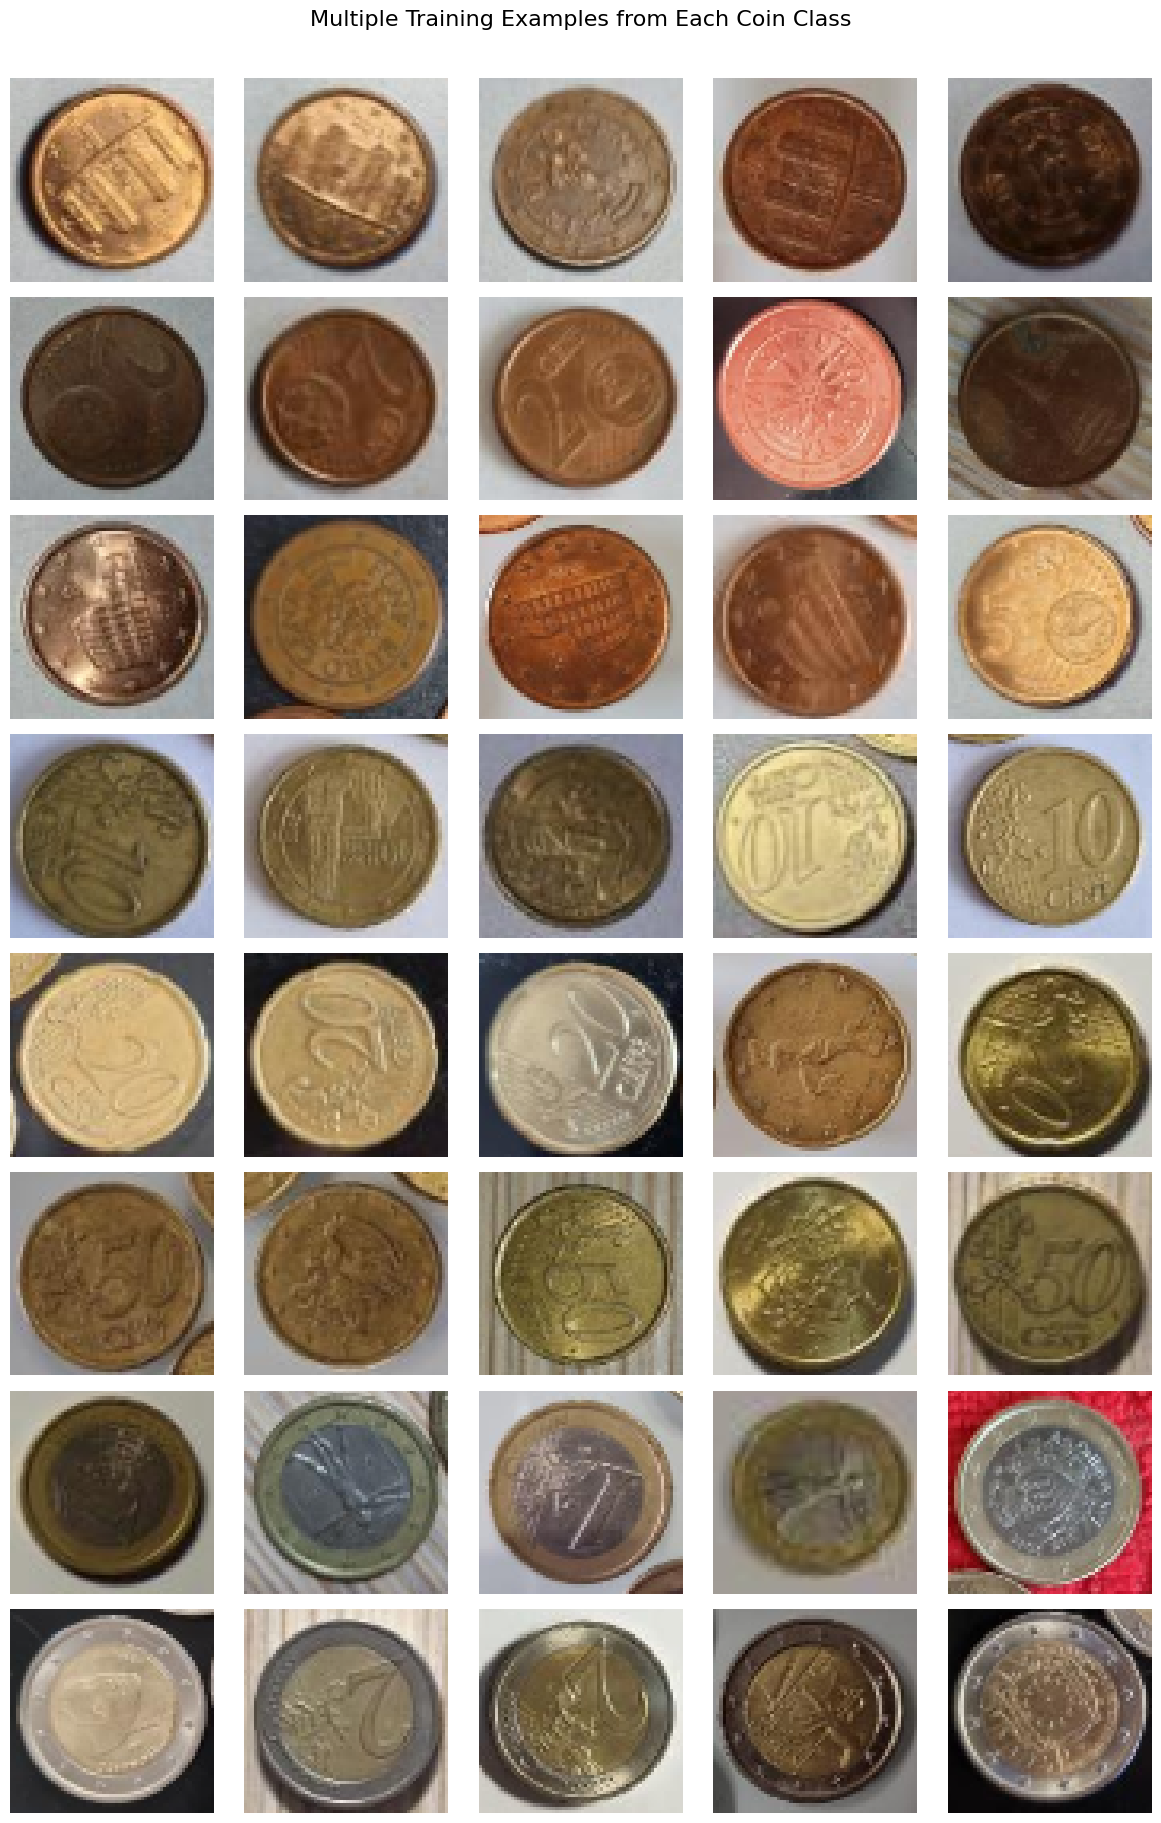

In [92]:
# Display multiple examples from each class

NUM_SAMPLES_PER_CLASS = 5

fig, axes = plt.subplots(
    len(CLASS_NAMES),
    NUM_SAMPLES_PER_CLASS,
    figsize=(12, 18)
)

for row_index, class_name in enumerate(CLASS_NAMES):
    image_paths = sorted((TRAIN_DIR / class_name).glob("*.png"))

    selected_paths = image_paths[:NUM_SAMPLES_PER_CLASS]

    for column_index, image_path in enumerate(selected_paths):
        image = Image.open(image_path).convert("RGB")

        axes[row_index, column_index].imshow(image)
        axes[row_index, column_index].axis("off")

        if column_index == 0:
            axes[row_index, column_index].set_ylabel(
                COIN_LABELS[class_name],
                rotation=0,
                labelpad=35,
                va="center"
            )

plt.suptitle(
    "Multiple Training Examples from Each Coin Class",
    fontsize=16,
    y=1.01
)
plt.tight_layout()
plt.show()

In [93]:
# Inspect image sizes and color modes across the complete dataset

image_records = []

for split_name, split_directory in {
    "train": TRAIN_DIR,
    "test": TEST_DIR
}.items():

    for class_name in CLASS_NAMES:
        image_paths = sorted((split_directory / class_name).glob("*.png"))

        for image_path in image_paths:
            with Image.open(image_path) as image:
                image_records.append({
                    "split": split_name,
                    "class_code": class_name,
                    "width": image.width,
                    "height": image.height,
                    "mode": image.mode,
                    "format": image.format,
                })

image_info_df = pd.DataFrame(image_records)

print("Number of inspected images:", len(image_info_df))
print("\nUnique image sizes:")
display(
    image_info_df[["width", "height"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("\nImage color modes:")
display(image_info_df["mode"].value_counts())

print("\nImage formats:")
display(image_info_df["format"].value_counts())

Number of inspected images: 960

Unique image sizes:


,width,height
0,64,64



Image color modes:


mode
RGB    960
Name: count, dtype: int64


Image formats:


format
PNG    960
Name: count, dtype: int64

In [94]:
# Calculate mean brightness for every image

brightness_records = []

for split_name, split_directory in {
    "train": TRAIN_DIR,
    "test": TEST_DIR
}.items():

    for class_name in CLASS_NAMES:
        image_paths = sorted((split_directory / class_name).glob("*.png"))

        for image_path in image_paths:
            image = Image.open(image_path).convert("L")
            image_array = np.asarray(image, dtype=np.float32)

            brightness_records.append({
                "split": split_name,
                "class_code": class_name,
                "coin_label": COIN_LABELS[class_name],
                "mean_brightness": image_array.mean(),
                "brightness_std": image_array.std(),
            })

brightness_df = pd.DataFrame(brightness_records)

brightness_df.head()

,split,class_code,coin_label,mean_brightness,brightness_std
0,train,001,1 cent,153.698486,44.750923
1,train,001,1 cent,144.116699,46.489372
2,train,001,1 cent,142.996338,40.224384
3,train,001,1 cent,110.473389,52.929333
4,train,001,1 cent,75.589355,52.025177


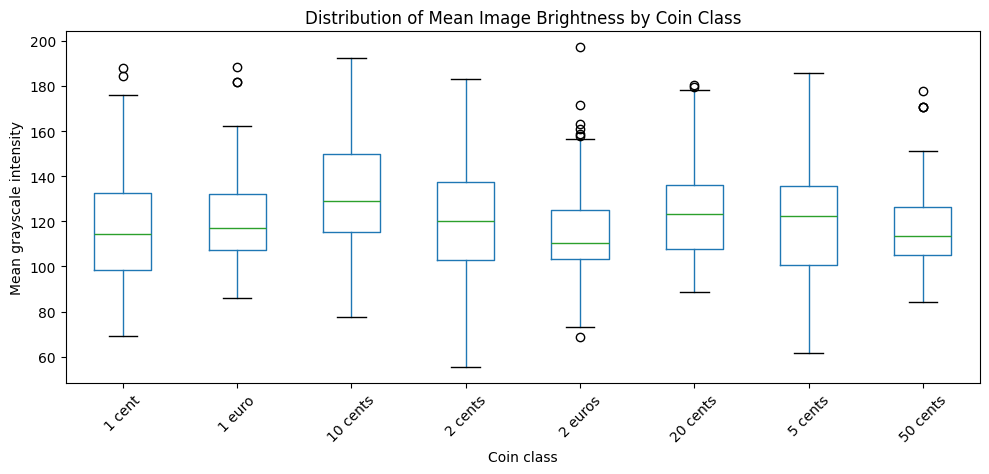

In [95]:
ax = brightness_df.boxplot(
    column="mean_brightness",
    by="coin_label",
    grid=False,
    rot=45,
    figsize=(10, 5)
)

ax.set_title("Distribution of Mean Image Brightness by Coin Class")
ax.set_xlabel("Coin class")
ax.set_ylabel("Mean grayscale intensity")

plt.suptitle("")
plt.tight_layout()
plt.show()

### Brightness Analysis

The brightness distributions vary both across and within coin classes. This confirms that illumination conditions are not uniform. Normalization and brightness-based data augmentation may help the classifier become more robust.

## 5. Baseline Model: Logistic Regression on Raw Pixels

As a simple baseline, each RGB image is normalized to the range [0, 1] and flattened into a one-dimensional feature vector. A multinomial Logistic Regression classifier is then trained to predict the eight coin classes.

In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import train_test_split

In [97]:
def load_images_as_arrays(directory):
    images = []
    labels = []
    paths = []

    for label_index, class_name in enumerate(CLASS_NAMES):
        image_paths = sorted((directory / class_name).glob("*.png"))

        for image_path in image_paths:
            with Image.open(image_path) as image:
                image = image.convert("RGB")
                image_array = np.asarray(image, dtype=np.float32) / 255.0

            images.append(image_array.flatten())
            labels.append(label_index)
            paths.append(image_path)

    X = np.asarray(images, dtype=np.float32)
    y = np.asarray(labels, dtype=np.int64)

    return X, y, paths


X_train_full, y_train_full, train_paths = load_images_as_arrays(TRAIN_DIR)
X_test, y_test, test_paths = load_images_as_arrays(TEST_DIR)

print("Full training features:", X_train_full.shape)
print("Full training labels:", y_train_full.shape)
print("Test features:", X_test.shape)
print("Test labels:", y_test.shape)

Full training features: (800, 12288)
Full training labels: (800,)
Test features: (160, 12288)
Test labels: (160,)


In [98]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (640, 12288) (640,)
Validation set: (160, 12288) (160,)
Test set: (160, 12288) (160,)


In [99]:
baseline_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

baseline_model.fit(X_train, y_train)

print("Baseline model training completed.")

Baseline model training completed.


In [100]:
y_val_pred = baseline_model.predict(X_val)

val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"Validation accuracy: {val_accuracy:.4f}")
print()

print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=[COIN_LABELS[name] for name in CLASS_NAMES],
        zero_division=0
    )
)

Validation accuracy: 0.6500

              precision    recall  f1-score   support

      1 cent       0.40      0.30      0.34        20
     2 cents       0.43      0.60      0.50        20
     5 cents       0.55      0.60      0.57        20
    10 cents       0.70      0.80      0.74        20
    20 cents       0.56      0.50      0.53        20
    50 cents       0.75      0.60      0.67        20
      1 euro       1.00      0.80      0.89        20
     2 euros       0.91      1.00      0.95        20

    accuracy                           0.65       160
   macro avg       0.66      0.65      0.65       160
weighted avg       0.66      0.65      0.65       160



In [101]:
y_test_pred_baseline = baseline_model.predict(X_test)

test_accuracy_baseline = accuracy_score(
    y_test,
    y_test_pred_baseline
)

print(f"Baseline test accuracy: {test_accuracy_baseline:.4f}")
print()

print(
    classification_report(
        y_test,
        y_test_pred_baseline,
        target_names=[COIN_LABELS[name] for name in CLASS_NAMES],
        zero_division=0
    )
)

Baseline test accuracy: 0.6813

              precision    recall  f1-score   support

      1 cent       0.60      0.45      0.51        20
     2 cents       0.55      0.85      0.67        20
     5 cents       0.60      0.60      0.60        20
    10 cents       0.68      0.65      0.67        20
    20 cents       0.50      0.55      0.52        20
    50 cents       0.75      0.45      0.56        20
      1 euro       0.95      1.00      0.98        20
     2 euros       0.90      0.90      0.90        20

    accuracy                           0.68       160
   macro avg       0.69      0.68      0.68       160
weighted avg       0.69      0.68      0.68       160



### Baseline Confusion Matrix

The confusion matrix is used to analyze which coin classes are most frequently confused by the baseline model.

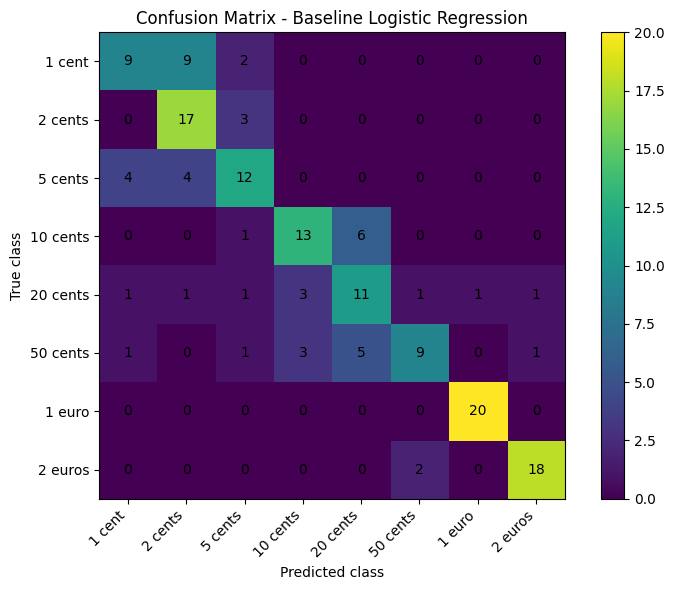

In [102]:
cm_baseline = confusion_matrix(y_test, y_test_pred_baseline)

plt.figure(figsize=(8, 6))
plt.imshow(cm_baseline)

plt.title("Confusion Matrix - Baseline Logistic Regression")
plt.xlabel("Predicted class")
plt.ylabel("True class")

plt.xticks(
    ticks=np.arange(len(CLASS_NAMES)),
    labels=[COIN_LABELS[name] for name in CLASS_NAMES],
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(CLASS_NAMES)),
    labels=[COIN_LABELS[name] for name in CLASS_NAMES]
)

for i in range(cm_baseline.shape[0]):
    for j in range(cm_baseline.shape[1]):
        plt.text(
            j,
            i,
            cm_baseline[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

### Monetary Misclassification Cost

In addition to classification accuracy, the assignment requires evaluating the cost of misclassification as the absolute difference between the predicted and true coin values in cents.

In [103]:
coin_values_array = np.array([COIN_VALUES[name] for name in CLASS_NAMES])

true_values_baseline = coin_values_array[y_test]
predicted_values_baseline = coin_values_array[y_test_pred_baseline]

absolute_value_errors_baseline = np.abs(
    predicted_values_baseline - true_values_baseline
)

mean_value_error_baseline = absolute_value_errors_baseline.mean()

print(f"Mean absolute monetary error - Baseline: {mean_value_error_baseline:.2f} cents")
print(f"Maximum monetary error - Baseline: {absolute_value_errors_baseline.max()} cents")

Mean absolute monetary error - Baseline: 8.16 cents
Maximum monetary error - Baseline: 180 cents


In [104]:
error_analysis_df = pd.DataFrame({
    "image_path": [str(path) for path in test_paths],
    "true_class": [COIN_LABELS[CLASS_NAMES[i]] for i in y_test],
    "predicted_class": [COIN_LABELS[CLASS_NAMES[i]] for i in y_test_pred_baseline],
    "true_value_cents": true_values_baseline,
    "predicted_value_cents": predicted_values_baseline,
    "absolute_error_cents": absolute_value_errors_baseline,
})

error_analysis_df.sort_values(
    by="absolute_error_cents",
    ascending=False
).head(10)

,image_path,true_class,predicted_class,true_value_cents,predicted_value_cents,absolute_error_cents
83,d:\UNIPV\Year 2\Machine Learning\euro-coin-cla...,20 cents,2 euros,20,200,180
107,d:\UNIPV\Year 2\Machine Learning\euro-coin-cla...,50 cents,2 euros,50,200,150
158,d:\UNIPV\Year 2\Machine Learning\euro-coin-cla...,2 euros,50 cents,200,50,150
154,d:\UNIPV\Year 2\Machine Learning\euro-coin-cla...,2 euros,50 cents,200,50,150
84,d:\UNIPV\Year 2\Machine Learning\euro-coin-cla...,20 cents,1 euro,20,100,80
104,d:\UNIPV\Year 2\Machine Learning\euro-coin-cla...,50 cents,1 cent,50,1,49
110,d:\UNIPV\Year 2\Machine Learning\euro-coin-cla...,50 cents,5 cents,50,5,45
115,d:\UNIPV\Year 2\Machine Learning\euro-coin-cla...,50 cents,10 cents,50,10,40
117,d:\UNIPV\Year 2\Machine Learning\euro-coin-cla...,50 cents,10 cents,50,10,40
108,d:\UNIPV\Year 2\Machine Learning\euro-coin-cla...,50 cents,10 cents,50,10,40


## 6. Cost-Sensitive Prediction

The baseline classifier predicts the class with the highest probability. However, the assignment also requires minimizing the monetary cost of misclassification, defined as the absolute difference between the predicted and true coin values.

To address this requirement, a cost-sensitive decision rule is applied to the probability outputs of the Logistic Regression model. Instead of selecting the class with maximum probability, the predicted class is chosen as the one with the minimum expected monetary cost.

In [105]:
# Cost matrix based on absolute differences between coin values

coin_values_array = np.array([COIN_VALUES[name] for name in CLASS_NAMES])

cost_matrix = np.abs(
    coin_values_array.reshape(-1, 1) - coin_values_array.reshape(1, -1)
)

cost_matrix_df = pd.DataFrame(
    cost_matrix,
    index=[COIN_LABELS[name] for name in CLASS_NAMES],
    columns=[COIN_LABELS[name] for name in CLASS_NAMES]
)

cost_matrix_df

,1 cent,2 cents,5 cents,10 cents,20 cents,50 cents,1 euro,2 euros
1 cent,0,1,4,9,19,49,99,199
2 cents,1,0,3,8,18,48,98,198
5 cents,4,3,0,5,15,45,95,195
10 cents,9,8,5,0,10,40,90,190
20 cents,19,18,15,10,0,30,80,180
50 cents,49,48,45,40,30,0,50,150
1 euro,99,98,95,90,80,50,0,100
2 euros,199,198,195,190,180,150,100,0


The cost matrix assigns zero cost to correct predictions and higher costs to mistakes involving coins with very different monetary values.

In [106]:
def cost_sensitive_predict(probabilities, cost_matrix):
    """
    Predict classes by minimizing expected monetary cost.

    probabilities: array of shape (n_samples, n_classes)
    cost_matrix: array of shape (n_true_classes, n_predicted_classes)

    Returns:
        predicted class indices
    """

    expected_costs = probabilities @ cost_matrix

    predictions = np.argmin(expected_costs, axis=1)

    return predictions

In [107]:
test_probabilities_baseline = baseline_model.predict_proba(X_test)

y_test_pred_cost_sensitive = cost_sensitive_predict(
    test_probabilities_baseline,
    cost_matrix
)

test_accuracy_cost_sensitive = accuracy_score(
    y_test,
    y_test_pred_cost_sensitive
)

true_values_cost_sensitive = coin_values_array[y_test]
predicted_values_cost_sensitive = coin_values_array[y_test_pred_cost_sensitive]

absolute_value_errors_cost_sensitive = np.abs(
    predicted_values_cost_sensitive - true_values_cost_sensitive
)

mean_value_error_cost_sensitive = absolute_value_errors_cost_sensitive.mean()
max_value_error_cost_sensitive = absolute_value_errors_cost_sensitive.max()

print(f"Cost-sensitive test accuracy: {test_accuracy_cost_sensitive:.4f}")
print(f"Mean absolute monetary error - Cost-sensitive: {mean_value_error_cost_sensitive:.2f} cents")
print(f"Maximum monetary error - Cost-sensitive: {max_value_error_cost_sensitive} cents")

Cost-sensitive test accuracy: 0.6875
Mean absolute monetary error - Cost-sensitive: 7.12 cents
Maximum monetary error - Cost-sensitive: 180 cents


In [108]:
print(
    classification_report(
        y_test,
        y_test_pred_cost_sensitive,
        target_names=[COIN_LABELS[name] for name in CLASS_NAMES],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      1 cent       0.60      0.45      0.51        20
     2 cents       0.59      0.85      0.69        20
     5 cents       0.65      0.65      0.65        20
    10 cents       0.62      0.65      0.63        20
    20 cents       0.45      0.50      0.48        20
    50 cents       0.77      0.50      0.61        20
      1 euro       0.95      1.00      0.98        20
     2 euros       0.95      0.90      0.92        20

    accuracy                           0.69       160
   macro avg       0.70      0.69      0.68       160
weighted avg       0.70      0.69      0.68       160



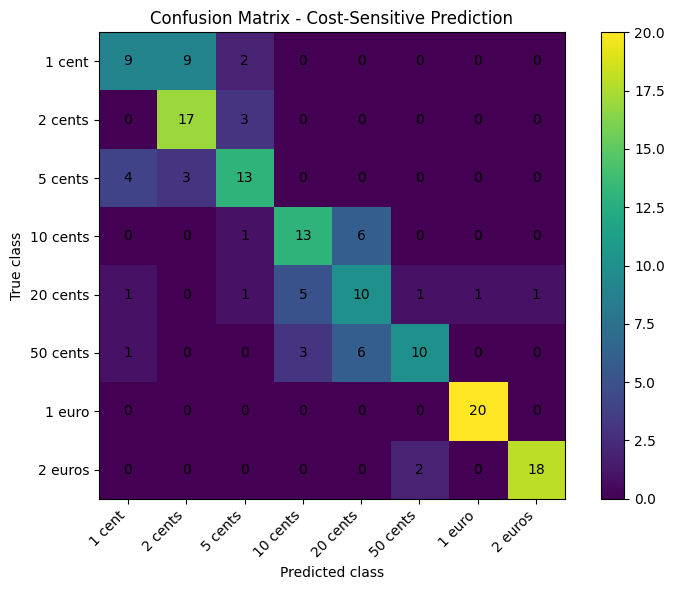

In [109]:
cm_cost_sensitive = confusion_matrix(y_test, y_test_pred_cost_sensitive)

plt.figure(figsize=(8, 6))
plt.imshow(cm_cost_sensitive)

plt.title("Confusion Matrix - Cost-Sensitive Prediction")
plt.xlabel("Predicted class")
plt.ylabel("True class")

plt.xticks(
    ticks=np.arange(len(CLASS_NAMES)),
    labels=[COIN_LABELS[name] for name in CLASS_NAMES],
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(CLASS_NAMES)),
    labels=[COIN_LABELS[name] for name in CLASS_NAMES]
)

for i in range(cm_cost_sensitive.shape[0]):
    for j in range(cm_cost_sensitive.shape[1]):
        plt.text(
            j,
            i,
            cm_cost_sensitive[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [110]:
comparison_df = pd.DataFrame({
    "model": [
        "Baseline Logistic Regression",
        "Cost-sensitive Logistic Regression"
    ],
    "test_accuracy": [
        test_accuracy_baseline,
        test_accuracy_cost_sensitive
    ],
    "mean_absolute_monetary_error_cents": [
        mean_value_error_baseline,
        mean_value_error_cost_sensitive
    ],
    "maximum_monetary_error_cents": [
        absolute_value_errors_baseline.max(),
        max_value_error_cost_sensitive
    ]
})

comparison_df

,model,test_accuracy,mean_absolute_monetary_error_cents,maximum_monetary_error_cents
0,Baseline Logistic Regression,0.68125,8.15625,180
1,Cost-sensitive Logistic Regression,0.68750,7.11875,180


### Cost-Sensitive Results

The cost-sensitive decision rule improved the test accuracy from 68.13% to 68.75%. More importantly, it reduced the mean absolute monetary error from 8.16 cents to 7.12 cents, corresponding to a reduction of approximately 12.7%.

The maximum monetary error remained 180 cents, indicating that at least one severe misclassification was still present. Overall, the results show that using the expected monetary cost as the decision criterion can reduce the average financial impact of classification errors without reducing classification accuracy.

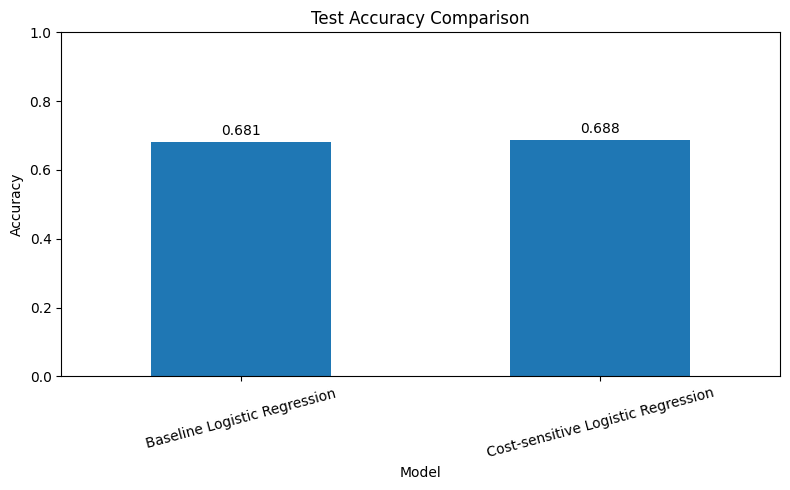

In [111]:
accuracy_comparison = comparison_df.set_index("model")["test_accuracy"]

ax = accuracy_comparison.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Test Accuracy Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=15)

for index, value in enumerate(accuracy_comparison):
    ax.text(
        index,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

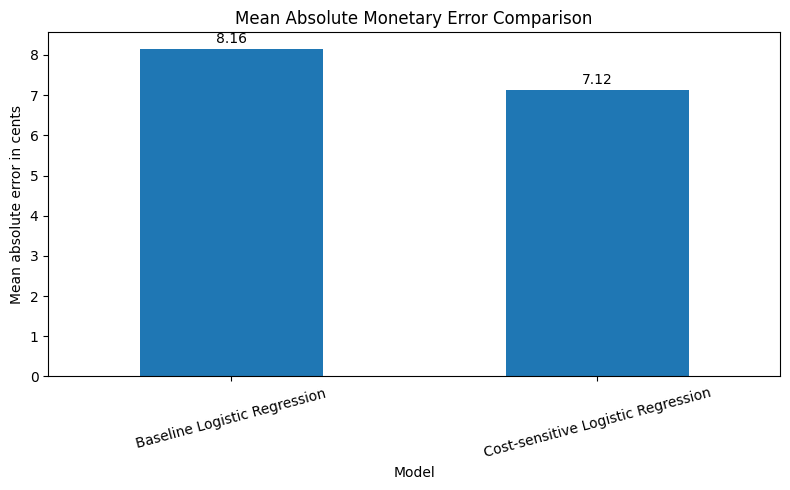

In [112]:
monetary_error_comparison = comparison_df.set_index(
    "model"
)["mean_absolute_monetary_error_cents"]

ax = monetary_error_comparison.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Mean Absolute Monetary Error Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Mean absolute error in cents")
ax.tick_params(axis="x", rotation=15)

for index, value in enumerate(monetary_error_comparison):
    ax.text(
        index,
        value + 0.15,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [113]:
cost_sensitive_errors_df = pd.DataFrame({
    "image_path": [str(path) for path in test_paths],
    "true_class": [
        COIN_LABELS[CLASS_NAMES[index]]
        for index in y_test
    ],
    "predicted_class": [
        COIN_LABELS[CLASS_NAMES[index]]
        for index in y_test_pred_cost_sensitive
    ],
    "true_value_cents": true_values_cost_sensitive,
    "predicted_value_cents": predicted_values_cost_sensitive,
    "absolute_error_cents": absolute_value_errors_cost_sensitive,
})

cost_sensitive_errors_df.sort_values(
    by="absolute_error_cents",
    ascending=False
).head(10)

,image_path,true_class,predicted_class,true_value_cents,predicted_value_cents,absolute_error_cents
83,d:\UNIPV\Year 2\Machine Learning\euro-coin-cla...,20 cents,2 euros,20,200,180
158,d:\UNIPV\Year 2\Machine Learning\euro-coin-cla...,2 euros,50 cents,200,50,150
154,d:\UNIPV\Year 2\Machine Learning\euro-coin-cla...,2 euros,50 cents,200,50,150
84,d:\UNIPV\Year 2\Machine Learning\euro-coin-cla...,20 cents,1 euro,20,100,80
104,d:\UNIPV\Year 2\Machine Learning\euro-coin-cla...,50 cents,1 cent,50,1,49
117,d:\UNIPV\Year 2\Machine Learning\euro-coin-cla...,50 cents,10 cents,50,10,40
108,d:\UNIPV\Year 2\Machine Learning\euro-coin-cla...,50 cents,10 cents,50,10,40
115,d:\UNIPV\Year 2\Machine Learning\euro-coin-cla...,50 cents,10 cents,50,10,40
118,d:\UNIPV\Year 2\Machine Learning\euro-coin-cla...,50 cents,20 cents,50,20,30
119,d:\UNIPV\Year 2\Machine Learning\euro-coin-cla...,50 cents,20 cents,50,20,30


## 7. Convolutional Neural Network

The raw-pixel Logistic Regression model cannot directly exploit spatial patterns such as edges, shapes, textures, and local coin details. Therefore, a Convolutional Neural Network is developed as a stronger image-classification model.

Data augmentation is applied during training to improve robustness to rotation, illumination, scale, and small positional variations.

In [114]:
import random

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

In [115]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Selected device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.12.0+cpu
Selected device: cpu


### Image Transformations

The training images are randomly rotated, translated, scaled, and adjusted in brightness and contrast. These transformations reflect the variability observed during exploratory data analysis.

Validation and test images are only converted to tensors and normalized, ensuring that model evaluation remains deterministic.

In [116]:
train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=180),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.08, 0.08),
        scale=(0.90, 1.10)
    ),
    transforms.ColorJitter(
        brightness=0.20,
        contrast=0.20,
        saturation=0.10
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

evaluation_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [117]:
full_train_dataset_augmented = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

full_train_dataset_evaluation = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=evaluation_transform
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=evaluation_transform
)

print("Detected classes:", full_train_dataset_augmented.classes)
print("Class-to-index mapping:", full_train_dataset_augmented.class_to_idx)
print("Training images:", len(full_train_dataset_augmented))
print("Test images:", len(test_dataset))

Detected classes: ['001', '002', '005', '010', '020', '050', '100', '200']
Class-to-index mapping: {'001': 0, '002': 1, '005': 2, '010': 3, '020': 4, '050': 5, '100': 6, '200': 7}
Training images: 800
Test images: 160


In [118]:
all_indices = np.arange(len(full_train_dataset_augmented))
all_targets = np.array(full_train_dataset_augmented.targets)

train_indices, validation_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=all_targets
)

train_dataset = Subset(
    full_train_dataset_augmented,
    train_indices
)

validation_dataset = Subset(
    full_train_dataset_evaluation,
    validation_indices
)

print("CNN training images:", len(train_dataset))
print("CNN validation images:", len(validation_dataset))
print("CNN test images:", len(test_dataset))

CNN training images: 640
CNN validation images: 160
CNN test images: 160


In [119]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))

Training batches: 20
Validation batches: 5
Test batches: 5


In [120]:
images_batch, labels_batch = next(iter(train_loader))

print("Image batch shape:", images_batch.shape)
print("Label batch shape:", labels_batch.shape)
print("Minimum normalized pixel value:", images_batch.min().item())
print("Maximum normalized pixel value:", images_batch.max().item())

Image batch shape: torch.Size([32, 3, 64, 64])
Label batch shape: torch.Size([32])
Minimum normalized pixel value: -1.0
Maximum normalized pixel value: 1.0


### CNN Architecture

The network contains three convolutional blocks. Each block uses convolution, batch normalization, ReLU activation, and max pooling. The extracted spatial features are then passed to fully connected layers for classification.

Dropout is used to reduce overfitting because the training dataset is relatively small.

In [121]:
class EuroCoinCNN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()

        self.features = nn.Sequential(
            # Input: 3 × 64 × 64
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            # Output: 32 × 32 × 32

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            # Output: 64 × 16 × 16

            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
            # Output: 128 × 8 × 8
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(p=0.40),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [122]:
cnn_model = EuroCoinCNN(
    num_classes=len(CLASS_NAMES)
).to(device)

print(cnn_model)

EuroCoinCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=Tr

In [123]:
total_parameters = sum(
    parameter.numel()
    for parameter in cnn_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in cnn_model.parameters()
    if parameter.requires_grad
)

print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")

Total parameters: 2,193,160
Trainable parameters: 2,193,160


### Training Configuration

Cross-entropy loss is used for multi-class classification. The Adam optimizer is applied with weight decay for regularization. A learning-rate scheduler reduces the learning rate when validation loss stops improving.

In [124]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    cnn_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)

Loss function: CrossEntropyLoss()
Optimizer: Adam


In [125]:
def run_epoch(model, data_loader, criterion, optimizer=None):
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            logits = model(images)
            loss = criterion(logits, labels)

            if is_training:
                loss.backward()
                optimizer.step()

        predictions = logits.argmax(dim=1)

        batch_size = labels.size(0)

        running_loss += loss.item() * batch_size
        correct_predictions += (
            predictions == labels
        ).sum().item()
        total_samples += batch_size

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    return epoch_loss, epoch_accuracy

In [126]:
NUM_EPOCHS = 25
EARLY_STOPPING_PATIENCE = 6

history = {
    "train_loss": [],
    "train_accuracy": [],
    "validation_loss": [],
    "validation_accuracy": []
}

best_validation_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0

MODEL_DIR = PROJECT_DIR / "outputs" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = MODEL_DIR / "best_cnn_model.pt"

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_accuracy = run_epoch(
        cnn_model,
        train_loader,
        criterion,
        optimizer
    )

    validation_loss, validation_accuracy = run_epoch(
        cnn_model,
        validation_loader,
        criterion
    )

    scheduler.step(validation_loss)

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["validation_loss"].append(validation_loss)
    history["validation_accuracy"].append(validation_accuracy)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train accuracy: {train_accuracy:.4f} | "
        f"Validation loss: {validation_loss:.4f} | "
        f"Validation accuracy: {validation_accuracy:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            cnn_model.state_dict(),
            BEST_MODEL_PATH
        )

    else:
        epochs_without_improvement += 1

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(
                f"\nEarly stopping triggered at epoch {epoch}."
            )
            break

print(f"\nBest epoch: {best_epoch}")
print(f"Best validation loss: {best_validation_loss:.4f}")
print("Saved model:", BEST_MODEL_PATH)

Epoch 01/25 | Train loss: 3.2692 | Train accuracy: 0.1906 | Validation loss: 1.7978 | Validation accuracy: 0.2375 | LR: 0.001000
Epoch 02/25 | Train loss: 1.8150 | Train accuracy: 0.2875 | Validation loss: 1.4693 | Validation accuracy: 0.4625 | LR: 0.001000
Epoch 03/25 | Train loss: 1.4880 | Train accuracy: 0.3641 | Validation loss: 1.1507 | Validation accuracy: 0.4875 | LR: 0.001000
Epoch 04/25 | Train loss: 1.3686 | Train accuracy: 0.4453 | Validation loss: 1.1544 | Validation accuracy: 0.4875 | LR: 0.001000
Epoch 05/25 | Train loss: 1.2573 | Train accuracy: 0.4500 | Validation loss: 1.0781 | Validation accuracy: 0.5062 | LR: 0.001000
Epoch 06/25 | Train loss: 1.2042 | Train accuracy: 0.4500 | Validation loss: 1.1243 | Validation accuracy: 0.4688 | LR: 0.001000
Epoch 07/25 | Train loss: 1.2011 | Train accuracy: 0.4750 | Validation loss: 1.0286 | Validation accuracy: 0.5250 | LR: 0.001000
Epoch 08/25 | Train loss: 1.1432 | Train accuracy: 0.5016 | Validation loss: 1.0556 | Validation 

In [127]:
cnn_model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device,
        weights_only=True
    )
)

cnn_model.eval()

print("Best CNN model loaded successfully.")

Best CNN model loaded successfully.


### Training Curves

Training and validation curves are examined to evaluate convergence and identify possible overfitting.

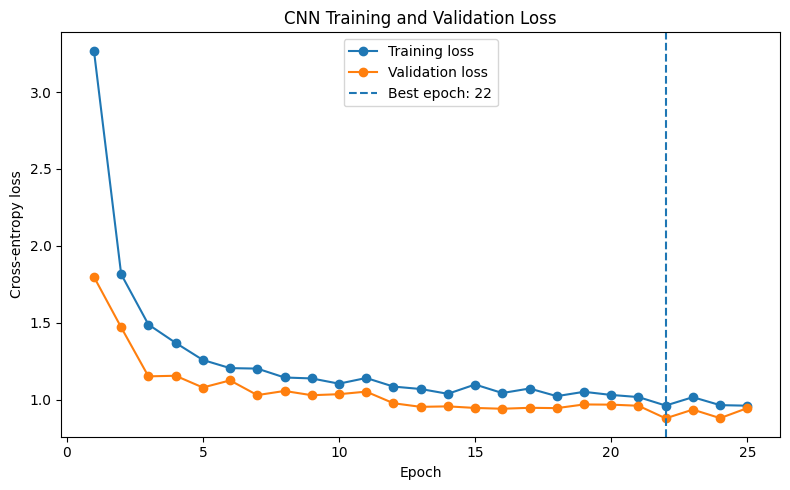

In [128]:
epochs_completed = range(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_completed,
    history["train_loss"],
    marker="o",
    label="Training loss"
)

plt.plot(
    epochs_completed,
    history["validation_loss"],
    marker="o",
    label="Validation loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch: {best_epoch}"
)

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.tight_layout()
plt.show()

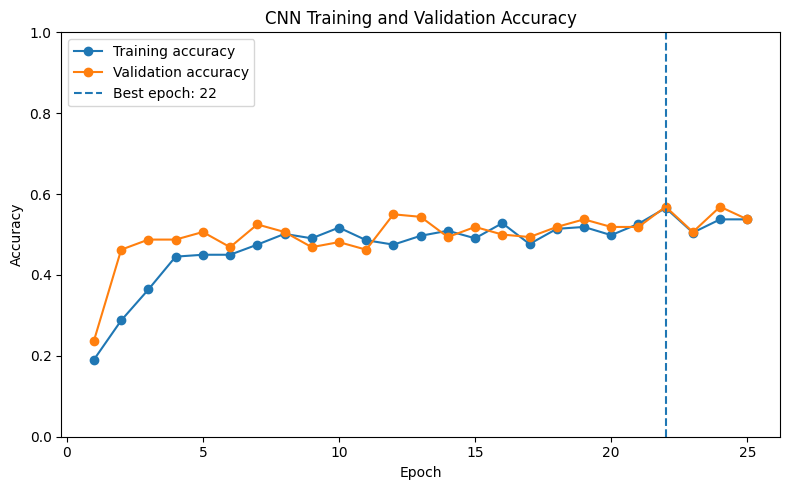

In [129]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_completed,
    history["train_accuracy"],
    marker="o",
    label="Training accuracy"
)

plt.plot(
    epochs_completed,
    history["validation_accuracy"],
    marker="o",
    label="Validation accuracy"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch: {best_epoch}"
)

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

### CNN Test Evaluation

The best CNN checkpoint, selected according to validation loss, is evaluated on the independent test set. Classification accuracy, class-level metrics, confusion matrix, and monetary error are calculated.

In [130]:
def predict_with_probabilities(model, data_loader):
    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)

            logits = model(images)
            probabilities = torch.softmax(logits, dim=1)
            predictions = probabilities.argmax(dim=1)

            all_labels.append(labels.cpu().numpy())
            all_predictions.append(predictions.cpu().numpy())
            all_probabilities.append(probabilities.cpu().numpy())

    true_labels = np.concatenate(all_labels)
    predicted_labels = np.concatenate(all_predictions)
    probabilities = np.concatenate(all_probabilities)

    return true_labels, predicted_labels, probabilities


y_test_cnn, y_test_pred_cnn, test_probabilities_cnn = (
    predict_with_probabilities(cnn_model, test_loader)
)

print("True labels shape:", y_test_cnn.shape)
print("Predictions shape:", y_test_pred_cnn.shape)
print("Probabilities shape:", test_probabilities_cnn.shape)

True labels shape: (160,)
Predictions shape: (160,)
Probabilities shape: (160, 8)


In [131]:
test_accuracy_cnn = accuracy_score(
    y_test_cnn,
    y_test_pred_cnn
)

print(f"CNN test accuracy: {test_accuracy_cnn:.4f}")
print()

print(
    classification_report(
        y_test_cnn,
        y_test_pred_cnn,
        target_names=[
            COIN_LABELS[name]
            for name in CLASS_NAMES
        ],
        zero_division=0
    )
)

CNN test accuracy: 0.6125

              precision    recall  f1-score   support

      1 cent       0.50      0.25      0.33        20
     2 cents       0.40      0.80      0.53        20
     5 cents       0.40      0.20      0.27        20
    10 cents       0.53      1.00      0.69        20
    20 cents       0.53      0.50      0.51        20
    50 cents       1.00      0.15      0.26        20
      1 euro       1.00      1.00      1.00        20
     2 euros       1.00      1.00      1.00        20

    accuracy                           0.61       160
   macro avg       0.67      0.61      0.57       160
weighted avg       0.67      0.61      0.57       160



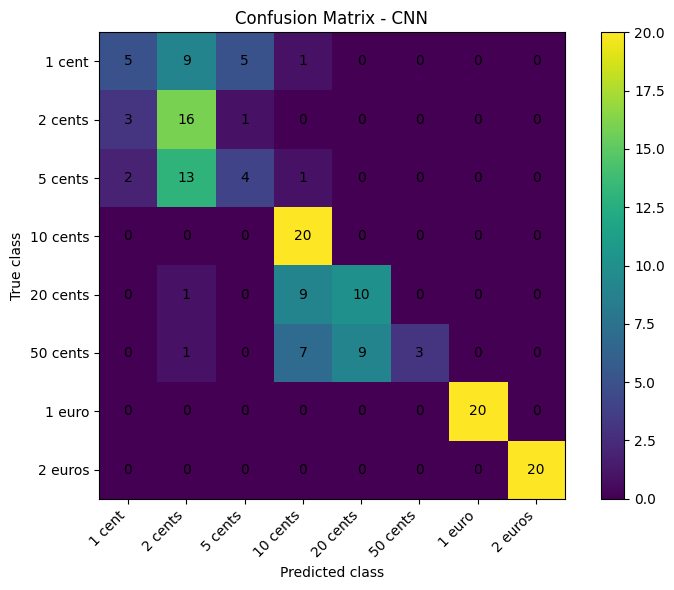

In [132]:
cm_cnn = confusion_matrix(
    y_test_cnn,
    y_test_pred_cnn
)

plt.figure(figsize=(8, 6))
plt.imshow(cm_cnn)

plt.title("Confusion Matrix - CNN")
plt.xlabel("Predicted class")
plt.ylabel("True class")

plt.xticks(
    ticks=np.arange(len(CLASS_NAMES)),
    labels=[
        COIN_LABELS[name]
        for name in CLASS_NAMES
    ],
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(CLASS_NAMES)),
    labels=[
        COIN_LABELS[name]
        for name in CLASS_NAMES
    ]
)

for row in range(cm_cnn.shape[0]):
    for column in range(cm_cnn.shape[1]):
        plt.text(
            column,
            row,
            cm_cnn[row, column],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [133]:
true_values_cnn = coin_values_array[y_test_cnn]
predicted_values_cnn = coin_values_array[y_test_pred_cnn]

absolute_value_errors_cnn = np.abs(
    predicted_values_cnn - true_values_cnn
)

mean_value_error_cnn = absolute_value_errors_cnn.mean()
max_value_error_cnn = absolute_value_errors_cnn.max()

print(
    f"Mean absolute monetary error - CNN: "
    f"{mean_value_error_cnn:.2f} cents"
)

print(
    f"Maximum monetary error - CNN: "
    f"{max_value_error_cnn} cents"
)

Mean absolute monetary error - CNN: 5.01 cents
Maximum monetary error - CNN: 48 cents


In [134]:
y_test_pred_cnn_cost_sensitive = cost_sensitive_predict(
    test_probabilities_cnn,
    cost_matrix
)

test_accuracy_cnn_cost_sensitive = accuracy_score(
    y_test_cnn,
    y_test_pred_cnn_cost_sensitive
)

predicted_values_cnn_cost_sensitive = coin_values_array[
    y_test_pred_cnn_cost_sensitive
]

absolute_value_errors_cnn_cost_sensitive = np.abs(
    predicted_values_cnn_cost_sensitive -
    true_values_cnn
)

mean_value_error_cnn_cost_sensitive = (
    absolute_value_errors_cnn_cost_sensitive.mean()
)

max_value_error_cnn_cost_sensitive = (
    absolute_value_errors_cnn_cost_sensitive.max()
)

print(
    f"Cost-sensitive CNN test accuracy: "
    f"{test_accuracy_cnn_cost_sensitive:.4f}"
)

print(
    f"Mean absolute monetary error - Cost-sensitive CNN: "
    f"{mean_value_error_cnn_cost_sensitive:.2f} cents"
)

print(
    f"Maximum monetary error - Cost-sensitive CNN: "
    f"{max_value_error_cnn_cost_sensitive} cents"
)

Cost-sensitive CNN test accuracy: 0.5813
Mean absolute monetary error - Cost-sensitive CNN: 5.67 cents
Maximum monetary error - Cost-sensitive CNN: 95 cents


In [135]:
final_comparison_df = pd.DataFrame({
    "model": [
        "Baseline Logistic Regression",
        "Cost-sensitive Logistic Regression",
        "CNN",
        "Cost-sensitive CNN"
    ],
    "test_accuracy": [
        test_accuracy_baseline,
        test_accuracy_cost_sensitive,
        test_accuracy_cnn,
        test_accuracy_cnn_cost_sensitive
    ],
    "mean_absolute_monetary_error_cents": [
        mean_value_error_baseline,
        mean_value_error_cost_sensitive,
        mean_value_error_cnn,
        mean_value_error_cnn_cost_sensitive
    ],
    "maximum_monetary_error_cents": [
        absolute_value_errors_baseline.max(),
        max_value_error_cost_sensitive,
        max_value_error_cnn,
        max_value_error_cnn_cost_sensitive
    ]
})

final_comparison_df

,model,test_accuracy,mean_absolute_monetary_error_cents,maximum_monetary_error_cents
0,Baseline Logistic Regression,0.68125,8.15625,180
1,Cost-sensitive Logistic Regression,0.68750,7.11875,180
2,CNN,0.61250,5.01250,48
3,Cost-sensitive CNN,0.58125,5.67500,95


### Final Model Comparison

The cost-sensitive Logistic Regression achieved the highest test accuracy at 68.75%, slightly outperforming the standard Logistic Regression model.

The standard CNN achieved a lower classification accuracy of 61.25%. However, it produced the lowest mean absolute monetary error at 5.01 cents and reduced the maximum monetary error from 180 cents to 48 cents. Therefore, although the CNN made more classification mistakes, its mistakes generally occurred between coins with closer monetary values.

Applying the cost-sensitive decision rule to the CNN did not improve its results. Accuracy decreased to 58.13%, while the mean and maximum monetary errors increased to 5.68 and 95 cents. This may indicate that the CNN probability estimates were not sufficiently calibrated for expected-cost decision-making.

Consequently, the cost-sensitive Logistic Regression is selected as the best accuracy-oriented model, while the standard CNN is selected as the best monetary-cost-oriented model.

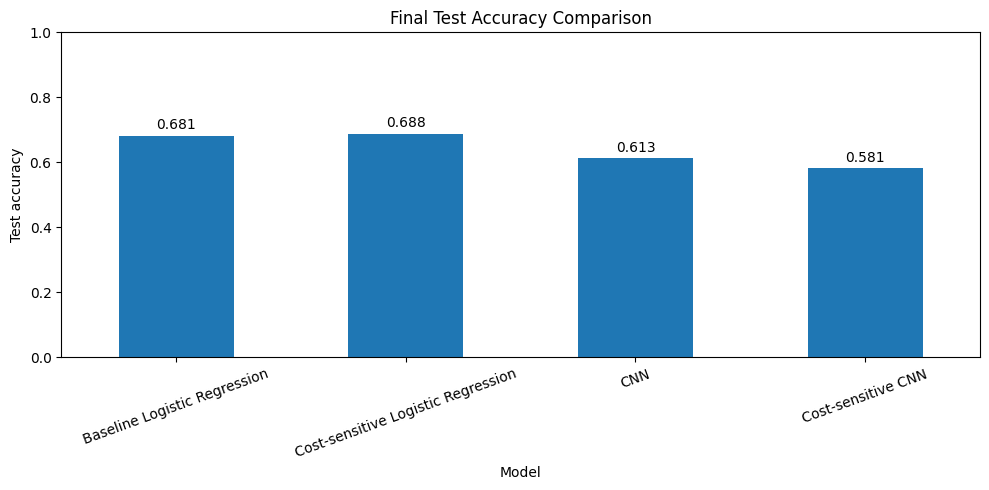

In [136]:
final_accuracy = final_comparison_df.set_index(
    "model"
)["test_accuracy"]

ax = final_accuracy.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_title("Final Test Accuracy Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Test accuracy")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=20)

for index, value in enumerate(final_accuracy):
    ax.text(
        index,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

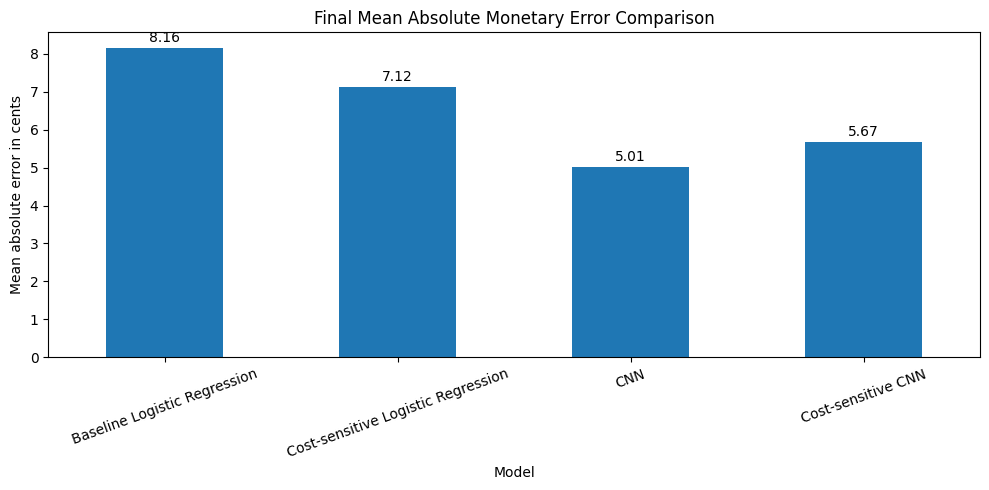

In [137]:
final_monetary_error = final_comparison_df.set_index(
    "model"
)["mean_absolute_monetary_error_cents"]

ax = final_monetary_error.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_title("Final Mean Absolute Monetary Error Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Mean absolute error in cents")
ax.tick_params(axis="x", rotation=20)

for index, value in enumerate(final_monetary_error):
    ax.text(
        index,
        value + 0.15,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [138]:
cnn_cost_reduction_percentage = (
    (mean_value_error_baseline - mean_value_error_cnn)
    / mean_value_error_baseline
    * 100
)

print(
    f"CNN monetary-error reduction relative to baseline: "
    f"{cnn_cost_reduction_percentage:.2f}%"
)

CNN monetary-error reduction relative to baseline: 38.54%


## 8. Transfer Learning with MobileNetV2

The custom CNN was trained from scratch on a relatively small dataset and did not outperform Logistic Regression in classification accuracy.

To obtain a stronger image classifier, transfer learning is applied using MobileNetV2 pretrained on ImageNet. The pretrained convolutional layers already contain useful representations for edges, textures, shapes, and object parts.

Training is performed in two stages:

1. The pretrained feature extractor is frozen and only a new classification head is trained.
2. The final convolutional blocks are unfrozen and fine-tuned using a smaller learning rate.

In [139]:
from torchvision import models
from torchvision.models import MobileNet_V2_Weights

In [140]:
MOBILENET_IMAGE_SIZE = 160

mobilenet_train_transform = transforms.Compose([
    transforms.Resize(
        (MOBILENET_IMAGE_SIZE, MOBILENET_IMAGE_SIZE)
    ),

    transforms.RandomRotation(degrees=25),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.05
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


mobilenet_evaluation_transform = transforms.Compose([
    transforms.Resize(
        (MOBILENET_IMAGE_SIZE, MOBILENET_IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [141]:
mobilenet_full_train_augmented = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=mobilenet_train_transform
)

mobilenet_full_train_evaluation = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=mobilenet_evaluation_transform
)

mobilenet_test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=mobilenet_evaluation_transform
)


mobilenet_train_dataset = Subset(
    mobilenet_full_train_augmented,
    train_indices
)

mobilenet_validation_dataset = Subset(
    mobilenet_full_train_evaluation,
    validation_indices
)


print(
    "MobileNet training images:",
    len(mobilenet_train_dataset)
)

print(
    "MobileNet validation images:",
    len(mobilenet_validation_dataset)
)

print(
    "MobileNet test images:",
    len(mobilenet_test_dataset)
)

MobileNet training images: 640
MobileNet validation images: 160
MobileNet test images: 160


In [142]:
MOBILENET_BATCH_SIZE = 16

mobilenet_train_loader = DataLoader(
    mobilenet_train_dataset,
    batch_size=MOBILENET_BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

mobilenet_validation_loader = DataLoader(
    mobilenet_validation_dataset,
    batch_size=MOBILENET_BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

mobilenet_test_loader = DataLoader(
    mobilenet_test_dataset,
    batch_size=MOBILENET_BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(
    "Training batches:",
    len(mobilenet_train_loader)
)

print(
    "Validation batches:",
    len(mobilenet_validation_loader)
)

print(
    "Test batches:",
    len(mobilenet_test_loader)
)

Training batches: 40
Validation batches: 10
Test batches: 10


In [143]:
mobilenet_images_batch, mobilenet_labels_batch = next(
    iter(mobilenet_train_loader)
)

print(
    "Image batch shape:",
    mobilenet_images_batch.shape
)

print(
    "Label batch shape:",
    mobilenet_labels_batch.shape
)

Image batch shape: torch.Size([16, 3, 160, 160])
Label batch shape: torch.Size([16])


In [144]:
mobilenet_weights = MobileNet_V2_Weights.DEFAULT

mobilenet_model = models.mobilenet_v2(
    weights=mobilenet_weights
)

mobilenet_model

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
  

In [145]:
for parameter in mobilenet_model.features.parameters():
    parameter.requires_grad = False

In [146]:
mobilenet_input_features = (
    mobilenet_model.classifier[1].in_features
)

mobilenet_model.classifier = nn.Sequential(
    nn.Dropout(p=0.30),

    nn.Linear(
        mobilenet_input_features,
        128
    ),

    nn.ReLU(),

    nn.Dropout(p=0.20),

    nn.Linear(
        128,
        len(CLASS_NAMES)
    )
)

mobilenet_model = mobilenet_model.to(device)

print(mobilenet_model.classifier)

Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1280, out_features=128, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=128, out_features=8, bias=True)
)


In [147]:
mobilenet_total_parameters = sum(
    parameter.numel()
    for parameter in mobilenet_model.parameters()
)

mobilenet_trainable_parameters = sum(
    parameter.numel()
    for parameter in mobilenet_model.parameters()
    if parameter.requires_grad
)

print(
    f"Total parameters: "
    f"{mobilenet_total_parameters:,}"
)

print(
    f"Trainable parameters: "
    f"{mobilenet_trainable_parameters:,}"
)

Total parameters: 2,388,872
Trainable parameters: 165,000


In [148]:
def run_transfer_epoch(
    model,
    data_loader,
    criterion,
    optimizer=None,
    freeze_backbone=False
):
    is_training = optimizer is not None

    if is_training:
        model.train()

        if freeze_backbone:
            model.features.eval()

    else:
        model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            logits = model(images)
            loss = criterion(logits, labels)

            if is_training:
                loss.backward()
                optimizer.step()

        predictions = logits.argmax(dim=1)

        batch_size = labels.size(0)

        running_loss += loss.item() * batch_size

        correct_predictions += (
            predictions == labels
        ).sum().item()

        total_samples += batch_size

    epoch_loss = running_loss / total_samples

    epoch_accuracy = (
        correct_predictions / total_samples
    )

    return epoch_loss, epoch_accuracy

### Stage 1: Training the Classification Head

During the first stage, all pretrained convolutional layers are frozen. Only the newly added classification layers are trained.

In [149]:
mobilenet_criterion = nn.CrossEntropyLoss()

mobilenet_head_optimizer = optim.Adam(
    mobilenet_model.classifier.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

HEAD_EPOCHS = 8

mobilenet_history = {
    "train_loss": [],
    "train_accuracy": [],
    "validation_loss": [],
    "validation_accuracy": []
}

In [150]:
mobilenet_criterion = nn.CrossEntropyLoss()

mobilenet_head_optimizer = optim.Adam(
    mobilenet_model.classifier.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

HEAD_EPOCHS = 8

mobilenet_history = {
    "train_loss": [],
    "train_accuracy": [],
    "validation_loss": [],
    "validation_accuracy": []
}

### Stage 2: Fine-Tuning the Final Feature Blocks

The final MobileNetV2 feature blocks are unfrozen and trained with a smaller learning rate. This allows the pretrained visual representations to adapt to the appearance of Euro coins without extensively modifying the entire network.

In [151]:
for parameter in mobilenet_model.features[-4:].parameters():
    parameter.requires_grad = True

In [152]:
mobilenet_trainable_parameters_finetuning = sum(
    parameter.numel()
    for parameter in mobilenet_model.parameters()
    if parameter.requires_grad
)

print(
    "Trainable parameters during fine-tuning:",
    f"{mobilenet_trainable_parameters_finetuning:,}"
)

Trainable parameters during fine-tuning: 1,691,080


In [153]:
mobilenet_trainable_parameters_finetuning = sum(
    parameter.numel()
    for parameter in mobilenet_model.parameters()
    if parameter.requires_grad
)

print(
    "Trainable parameters during fine-tuning:",
    f"{mobilenet_trainable_parameters_finetuning:,}"
)

Trainable parameters during fine-tuning: 1,691,080


In [154]:
FINETUNE_EPOCHS = 15
FINETUNE_PATIENCE = 5

best_mobilenet_validation_loss = float("inf")
best_mobilenet_validation_accuracy = 0.0
best_mobilenet_epoch = 0
mobilenet_epochs_without_improvement = 0

MOBILENET_MODEL_PATH = (
    MODEL_DIR / "best_mobilenet_v2.pt"
)

In [156]:
mobilenet_finetune_optimizer = optim.Adam(
    filter(
        lambda parameter: parameter.requires_grad,
        mobilenet_model.parameters()
    ),
    lr=0.0001,
    weight_decay=1e-4
)

mobilenet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    mobilenet_finetune_optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Fine-tuning optimizer created.")

Fine-tuning optimizer created.


In [157]:
for epoch in range(
    1,
    FINETUNE_EPOCHS + 1
):
    train_loss, train_accuracy = run_transfer_epoch(
        mobilenet_model,
        mobilenet_train_loader,
        mobilenet_criterion,
        optimizer=mobilenet_finetune_optimizer,
        freeze_backbone=False
    )

    validation_loss, validation_accuracy = (
        run_transfer_epoch(
            mobilenet_model,
            mobilenet_validation_loader,
            mobilenet_criterion
        )
    )

    mobilenet_scheduler.step(validation_loss)

    mobilenet_history["train_loss"].append(
        train_loss
    )

    mobilenet_history["train_accuracy"].append(
        train_accuracy
    )

    mobilenet_history["validation_loss"].append(
        validation_loss
    )

    mobilenet_history["validation_accuracy"].append(
        validation_accuracy
    )

    current_learning_rate = (
        mobilenet_finetune_optimizer
        .param_groups[0]["lr"]
    )

    print(
        f"Fine-tune epoch "
        f"{epoch:02d}/{FINETUNE_EPOCHS} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train accuracy: {train_accuracy:.4f} | "
        f"Validation loss: {validation_loss:.4f} | "
        f"Validation accuracy: "
        f"{validation_accuracy:.4f} | "
        f"LR: {current_learning_rate:.6f}"
    )

    if validation_loss < best_mobilenet_validation_loss:
        best_mobilenet_validation_loss = validation_loss

        best_mobilenet_validation_accuracy = (
            validation_accuracy
        )

        best_mobilenet_epoch = epoch

        mobilenet_epochs_without_improvement = 0

        torch.save(
            mobilenet_model.state_dict(),
            MOBILENET_MODEL_PATH
        )

    else:
        mobilenet_epochs_without_improvement += 1

        if (
            mobilenet_epochs_without_improvement
            >= FINETUNE_PATIENCE
        ):
            print(
                "\nMobileNet early stopping "
                f"at fine-tuning epoch {epoch}."
            )
            break

Fine-tune epoch 01/15 | Train loss: 2.0524 | Train accuracy: 0.1797 | Validation loss: 2.0393 | Validation accuracy: 0.2313 | LR: 0.000100
Fine-tune epoch 02/15 | Train loss: 1.9167 | Train accuracy: 0.3906 | Validation loss: 1.9244 | Validation accuracy: 0.3312 | LR: 0.000100
Fine-tune epoch 03/15 | Train loss: 1.6758 | Train accuracy: 0.4969 | Validation loss: 1.6269 | Validation accuracy: 0.4688 | LR: 0.000100
Fine-tune epoch 04/15 | Train loss: 1.3451 | Train accuracy: 0.5687 | Validation loss: 1.3429 | Validation accuracy: 0.5500 | LR: 0.000100
Fine-tune epoch 05/15 | Train loss: 1.0983 | Train accuracy: 0.5953 | Validation loss: 1.0862 | Validation accuracy: 0.6188 | LR: 0.000100
Fine-tune epoch 06/15 | Train loss: 0.9317 | Train accuracy: 0.6625 | Validation loss: 0.9212 | Validation accuracy: 0.6875 | LR: 0.000100
Fine-tune epoch 07/15 | Train loss: 0.8215 | Train accuracy: 0.7203 | Validation loss: 0.8311 | Validation accuracy: 0.7000 | LR: 0.000100
Fine-tune epoch 08/15 | Tra

In [158]:
print(
    "\nBest MobileNet fine-tuning epoch:",
    best_mobilenet_epoch
)

print(
    "Best MobileNet validation loss:",
    f"{best_mobilenet_validation_loss:.4f}"
)

print(
    "Validation accuracy at best-loss epoch:",
    f"{best_mobilenet_validation_accuracy:.4f}"
)

print(
    "Saved model:",
    MOBILENET_MODEL_PATH
)


Best MobileNet fine-tuning epoch: 13
Best MobileNet validation loss: 0.5545
Validation accuracy at best-loss epoch: 0.7875
Saved model: d:\UNIPV\Year 2\Machine Learning\euro-coin-classification\outputs\models\best_mobilenet_v2.pt


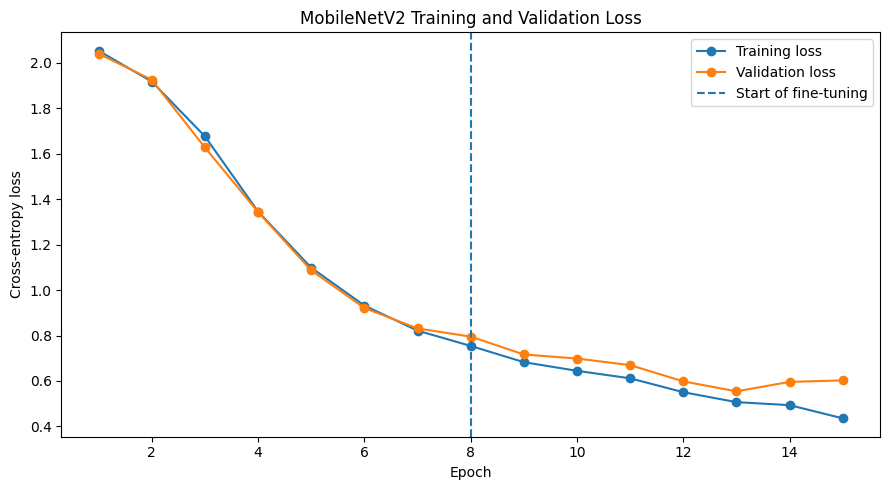

In [160]:
mobilenet_epochs_completed = range(
    1,
    len(mobilenet_history["train_loss"]) + 1
)

plt.figure(figsize=(9, 5))

plt.plot(
    mobilenet_epochs_completed,
    mobilenet_history["train_loss"],
    marker="o",
    label="Training loss"
)

plt.plot(
    mobilenet_epochs_completed,
    mobilenet_history["validation_loss"],
    marker="o",
    label="Validation loss"
)

plt.axvline(
    HEAD_EPOCHS,
    linestyle="--",
    label="Start of fine-tuning"
)

plt.title(
    "MobileNetV2 Training and Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.tight_layout()
plt.show()

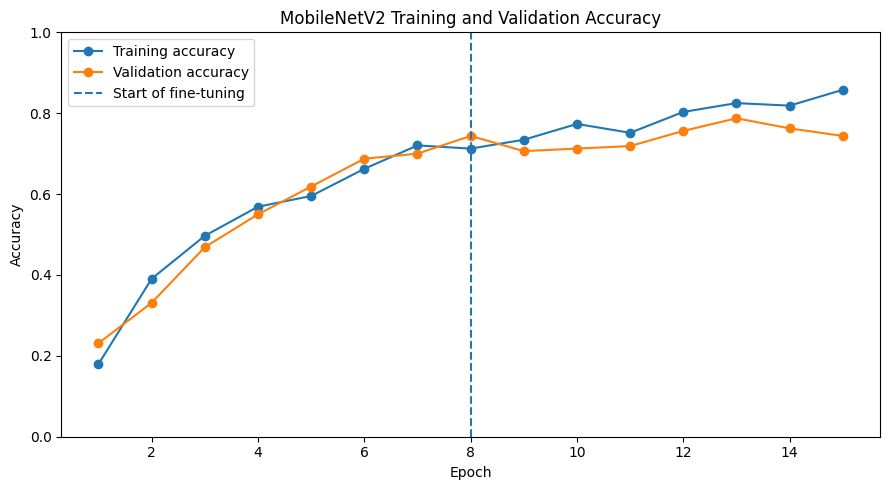

In [161]:
plt.figure(figsize=(9, 5))

plt.plot(
    mobilenet_epochs_completed,
    mobilenet_history["train_accuracy"],
    marker="o",
    label="Training accuracy"
)

plt.plot(
    mobilenet_epochs_completed,
    mobilenet_history["validation_accuracy"],
    marker="o",
    label="Validation accuracy"
)

plt.axvline(
    HEAD_EPOCHS,
    linestyle="--",
    label="Start of fine-tuning"
)

plt.title(
    "MobileNetV2 Training and Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

### MobileNetV2 Test Evaluation

The best MobileNetV2 checkpoint, selected according to validation loss, is evaluated on the independent test set. Standard classification metrics and monetary misclassification costs are computed.

In [162]:
y_test_mobilenet, y_test_pred_mobilenet, test_probabilities_mobilenet = (
    predict_with_probabilities(
        mobilenet_model,
        mobilenet_test_loader
    )
)

print("True labels shape:", y_test_mobilenet.shape)
print("Predictions shape:", y_test_pred_mobilenet.shape)
print("Probabilities shape:", test_probabilities_mobilenet.shape)

True labels shape: (160,)
Predictions shape: (160,)
Probabilities shape: (160, 8)


In [163]:
test_accuracy_mobilenet = accuracy_score(
    y_test_mobilenet,
    y_test_pred_mobilenet
)

print(
    f"MobileNetV2 test accuracy: "
    f"{test_accuracy_mobilenet:.4f}"
)

print()

print(
    classification_report(
        y_test_mobilenet,
        y_test_pred_mobilenet,
        target_names=[
            COIN_LABELS[name]
            for name in CLASS_NAMES
        ],
        zero_division=0
    )
)

MobileNetV2 test accuracy: 0.7812

              precision    recall  f1-score   support

      1 cent       0.52      0.65      0.58        20
     2 cents       0.62      0.50      0.56        20
     5 cents       0.80      0.80      0.80        20
    10 cents       0.73      0.80      0.76        20
    20 cents       0.73      0.80      0.76        20
    50 cents       0.93      0.70      0.80        20
      1 euro       1.00      1.00      1.00        20
     2 euros       1.00      1.00      1.00        20

    accuracy                           0.78       160
   macro avg       0.79      0.78      0.78       160
weighted avg       0.79      0.78      0.78       160



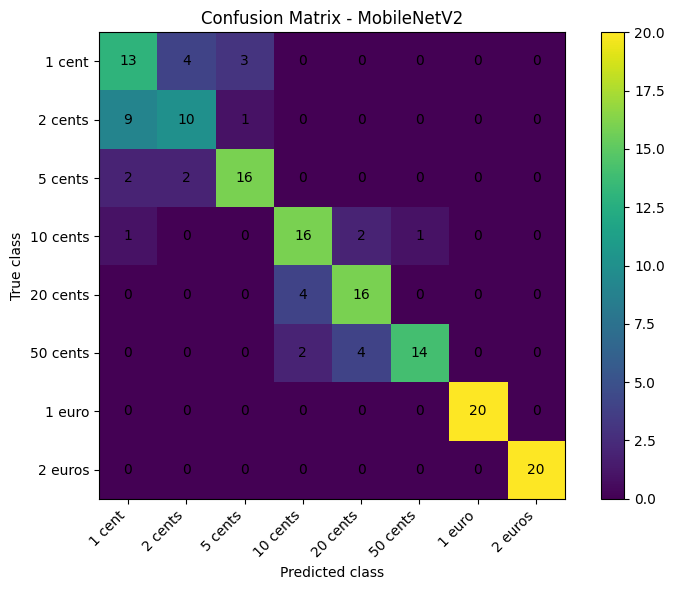

In [164]:
cm_mobilenet = confusion_matrix(
    y_test_mobilenet,
    y_test_pred_mobilenet
)

plt.figure(figsize=(8, 6))
plt.imshow(cm_mobilenet)

plt.title("Confusion Matrix - MobileNetV2")
plt.xlabel("Predicted class")
plt.ylabel("True class")

plt.xticks(
    ticks=np.arange(len(CLASS_NAMES)),
    labels=[
        COIN_LABELS[name]
        for name in CLASS_NAMES
    ],
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(CLASS_NAMES)),
    labels=[
        COIN_LABELS[name]
        for name in CLASS_NAMES
    ]
)

for row in range(cm_mobilenet.shape[0]):
    for column in range(cm_mobilenet.shape[1]):
        plt.text(
            column,
            row,
            cm_mobilenet[row, column],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [165]:
true_values_mobilenet = coin_values_array[
    y_test_mobilenet
]

predicted_values_mobilenet = coin_values_array[
    y_test_pred_mobilenet
]

absolute_value_errors_mobilenet = np.abs(
    predicted_values_mobilenet -
    true_values_mobilenet
)

mean_value_error_mobilenet = (
    absolute_value_errors_mobilenet.mean()
)

max_value_error_mobilenet = (
    absolute_value_errors_mobilenet.max()
)

print(
    f"Mean absolute monetary error - MobileNetV2: "
    f"{mean_value_error_mobilenet:.2f} cents"
)

print(
    f"Maximum monetary error - MobileNetV2: "
    f"{max_value_error_mobilenet} cents"
)

Mean absolute monetary error - MobileNetV2: 2.19 cents
Maximum monetary error - MobileNetV2: 40 cents


In [166]:
y_test_pred_mobilenet_cost_sensitive = (
    cost_sensitive_predict(
        test_probabilities_mobilenet,
        cost_matrix
    )
)

test_accuracy_mobilenet_cost_sensitive = accuracy_score(
    y_test_mobilenet,
    y_test_pred_mobilenet_cost_sensitive
)

predicted_values_mobilenet_cost_sensitive = (
    coin_values_array[
        y_test_pred_mobilenet_cost_sensitive
    ]
)

absolute_value_errors_mobilenet_cost_sensitive = np.abs(
    predicted_values_mobilenet_cost_sensitive -
    true_values_mobilenet
)

mean_value_error_mobilenet_cost_sensitive = (
    absolute_value_errors_mobilenet_cost_sensitive.mean()
)

max_value_error_mobilenet_cost_sensitive = (
    absolute_value_errors_mobilenet_cost_sensitive.max()
)

print(
    f"Cost-sensitive MobileNetV2 test accuracy: "
    f"{test_accuracy_mobilenet_cost_sensitive:.4f}"
)

print(
    f"Mean absolute monetary error - "
    f"Cost-sensitive MobileNetV2: "
    f"{mean_value_error_mobilenet_cost_sensitive:.2f} cents"
)

print(
    f"Maximum monetary error - "
    f"Cost-sensitive MobileNetV2: "
    f"{max_value_error_mobilenet_cost_sensitive} cents"
)

Cost-sensitive MobileNetV2 test accuracy: 0.7875
Mean absolute monetary error - Cost-sensitive MobileNetV2: 2.52 cents
Maximum monetary error - Cost-sensitive MobileNetV2: 40 cents


## 9. Final Model Comparison

All trained models are compared using classification accuracy, mean absolute monetary error, and maximum monetary error. This comparison identifies both the best classification-oriented model and the best cost-oriented model.

In [167]:
complete_comparison_df = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "Cost-sensitive Logistic Regression",
        "Custom CNN",
        "Cost-sensitive Custom CNN",
        "MobileNetV2",
        "Cost-sensitive MobileNetV2"
    ],
    "test_accuracy": [
        test_accuracy_baseline,
        test_accuracy_cost_sensitive,
        test_accuracy_cnn,
        test_accuracy_cnn_cost_sensitive,
        test_accuracy_mobilenet,
        test_accuracy_mobilenet_cost_sensitive
    ],
    "mean_absolute_monetary_error_cents": [
        mean_value_error_baseline,
        mean_value_error_cost_sensitive,
        mean_value_error_cnn,
        mean_value_error_cnn_cost_sensitive,
        mean_value_error_mobilenet,
        mean_value_error_mobilenet_cost_sensitive
    ],
    "maximum_monetary_error_cents": [
        absolute_value_errors_baseline.max(),
        max_value_error_cost_sensitive,
        max_value_error_cnn,
        max_value_error_cnn_cost_sensitive,
        max_value_error_mobilenet,
        max_value_error_mobilenet_cost_sensitive
    ]
})

complete_comparison_df

,model,test_accuracy,mean_absolute_monetary_error_cents,maximum_monetary_error_cents
0,Logistic Regression,0.68125,8.15625,180
1,Cost-sensitive Logistic Regression,0.68750,7.11875,180
2,Custom CNN,0.61250,5.01250,48
3,Cost-sensitive Custom CNN,0.58125,5.67500,95
4,MobileNetV2,0.78125,2.19375,40
5,Cost-sensitive MobileNetV2,0.78750,2.51875,40


In [168]:
complete_comparison_df.sort_values(
    by="test_accuracy",
    ascending=False
)

,model,test_accuracy,mean_absolute_monetary_error_cents,maximum_monetary_error_cents
5,Cost-sensitive MobileNetV2,0.78750,2.51875,40
4,MobileNetV2,0.78125,2.19375,40
1,Cost-sensitive Logistic Regression,0.68750,7.11875,180
0,Logistic Regression,0.68125,8.15625,180
2,Custom CNN,0.61250,5.01250,48
3,Cost-sensitive Custom CNN,0.58125,5.67500,95


In [169]:
complete_comparison_df.sort_values(
    by="mean_absolute_monetary_error_cents",
    ascending=True
)

,model,test_accuracy,mean_absolute_monetary_error_cents,maximum_monetary_error_cents
4,MobileNetV2,0.78125,2.19375,40
5,Cost-sensitive MobileNetV2,0.78750,2.51875,40
2,Custom CNN,0.61250,5.01250,48
3,Cost-sensitive Custom CNN,0.58125,5.67500,95
1,Cost-sensitive Logistic Regression,0.68750,7.11875,180
0,Logistic Regression,0.68125,8.15625,180


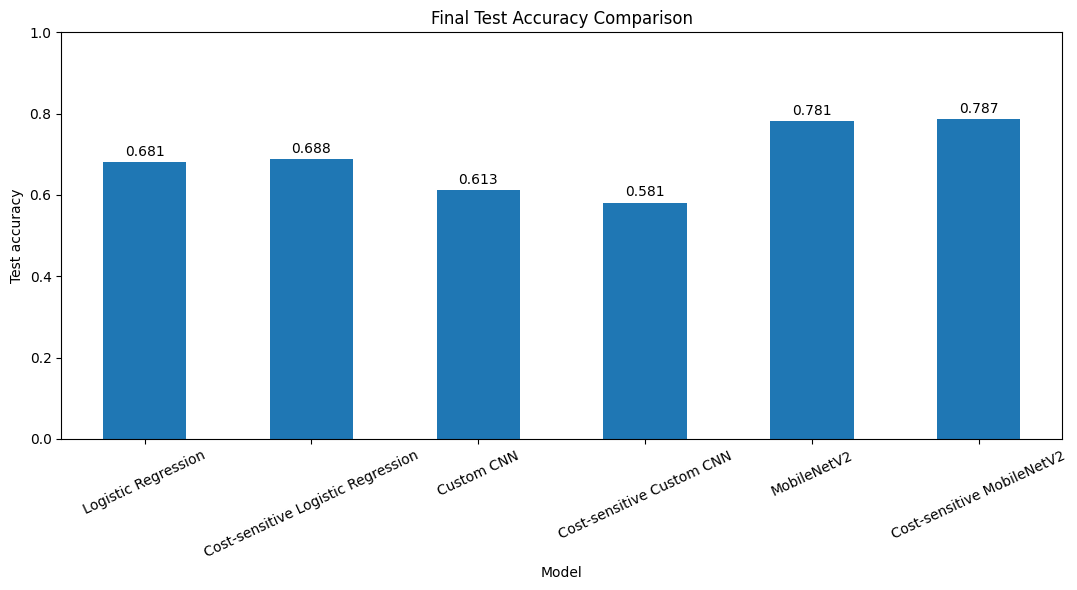

In [170]:
accuracy_values = complete_comparison_df.set_index(
    "model"
)["test_accuracy"]

ax = accuracy_values.plot(
    kind="bar",
    figsize=(11, 6)
)

ax.set_title("Final Test Accuracy Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Test accuracy")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=25)

for index, value in enumerate(accuracy_values):
    ax.text(
        index,
        value + 0.015,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

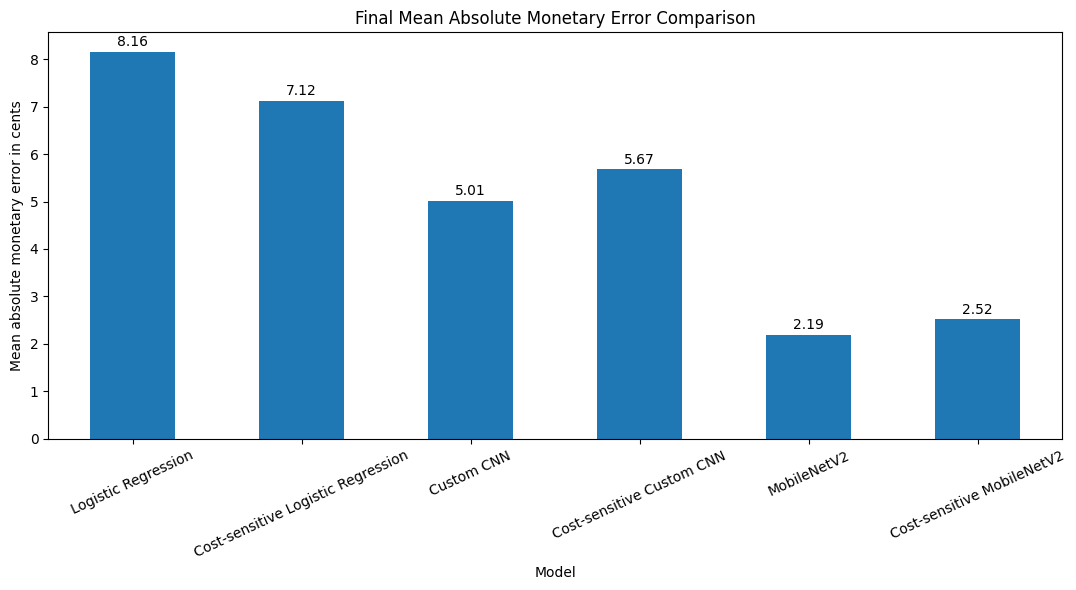

In [171]:
monetary_errors = complete_comparison_df.set_index(
    "model"
)["mean_absolute_monetary_error_cents"]

ax = monetary_errors.plot(
    kind="bar",
    figsize=(11, 6)
)

ax.set_title("Final Mean Absolute Monetary Error Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Mean absolute monetary error in cents")
ax.tick_params(axis="x", rotation=25)

for index, value in enumerate(monetary_errors):
    ax.text(
        index,
        value + 0.12,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [172]:
accuracy_improvement_points = (
    test_accuracy_mobilenet -
    test_accuracy_baseline
) * 100

monetary_error_reduction_percentage = (
    (
        mean_value_error_baseline -
        mean_value_error_mobilenet
    )
    / mean_value_error_baseline
    * 100
)

print(
    f"MobileNetV2 accuracy improvement over baseline: "
    f"{accuracy_improvement_points:.2f} percentage points"
)

print(
    f"MobileNetV2 monetary-error reduction over baseline: "
    f"{monetary_error_reduction_percentage:.2f}%"
)

MobileNetV2 accuracy improvement over baseline: 10.00 percentage points
MobileNetV2 monetary-error reduction over baseline: 73.10%


### Final Results Discussion

MobileNetV2 substantially outperformed both Logistic Regression and the custom CNN. The standard MobileNetV2 achieved a test accuracy of 78.12%, compared with 68.13% for the baseline Logistic Regression model.

MobileNetV2 also achieved the lowest mean absolute monetary error of 2.19 cents and limited the maximum monetary error to 40 cents. This represents an approximate 73% reduction in average monetary error relative to the Logistic Regression baseline.

The cost-sensitive MobileNetV2 obtained the highest classification accuracy at 78.75%, correctly classifying one additional test image. However, its mean monetary error increased from 2.19 to 2.52 cents. Therefore, the cost-sensitive decision rule did not improve the monetary objective for this model.

The standard MobileNetV2 is selected as the preferred overall model because it provides the best balance between classification accuracy and monetary error. The cost-sensitive MobileNetV2 is retained as the model with the highest classification accuracy.

## 10. Conclusion

This project investigated Euro coin image classification using Logistic Regression, a custom Convolutional Neural Network, and transfer learning with MobileNetV2.

The Logistic Regression baseline achieved a test accuracy of 68.13% and a mean absolute monetary error of 8.16 cents. The custom CNN reduced the monetary cost of errors but did not improve classification accuracy.

Transfer learning with MobileNetV2 produced the strongest overall results. The standard MobileNetV2 achieved 78.12% test accuracy, a mean absolute monetary error of 2.19 cents, and a maximum monetary error of 40 cents. This corresponds to a 10 percentage-point improvement in accuracy and approximately a 73% reduction in mean monetary error compared with the baseline.

The cost-sensitive MobileNetV2 achieved the highest test accuracy of 78.75%, but its mean monetary error increased to 2.52 cents. Therefore, the standard MobileNetV2 was selected as the preferred overall model because it provided the best balance between classification accuracy and monetary cost.

The results demonstrate that transfer learning is particularly effective for small image datasets and that classification accuracy alone is not sufficient when different prediction errors have different practical costs.

In [174]:
RESULTS_DIR = PROJECT_DIR / "outputs" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

complete_comparison_df.to_csv(
    RESULTS_DIR / "model_comparison.csv",
    index=False
)

print("Results saved to:", RESULTS_DIR / "model_comparison.csv")

Results saved to: d:\UNIPV\Year 2\Machine Learning\euro-coin-classification\outputs\results\model_comparison.csv


In [175]:
FINAL_MODEL_PATH = MODEL_DIR / "final_mobilenet_v2_checkpoint.pt"

torch.save(
    {
        "model_state_dict": mobilenet_model.state_dict(),
        "class_names": CLASS_NAMES,
        "coin_labels": COIN_LABELS,
        "coin_values": COIN_VALUES,
        "image_size": MOBILENET_IMAGE_SIZE,
        "test_accuracy": test_accuracy_mobilenet,
        "mean_monetary_error_cents": mean_value_error_mobilenet,
    },
    FINAL_MODEL_PATH
)

print("Final model checkpoint saved to:", FINAL_MODEL_PATH)

Final model checkpoint saved to: d:\UNIPV\Year 2\Machine Learning\euro-coin-classification\outputs\models\final_mobilenet_v2_checkpoint.pt


In [177]:
from pathlib import Path

NOTEBOOK_PATH = (
    PROJECT_DIR
    / "notebooks"
    / "euro_coin_classification.ipynb"
)

print("Notebook path:", NOTEBOOK_PATH)
print("File exists:", NOTEBOOK_PATH.exists())

if NOTEBOOK_PATH.exists():
    print("File size:", NOTEBOOK_PATH.stat().st_size, "bytes")

Notebook path: d:\UNIPV\Year 2\Machine Learning\euro-coin-classification\notebooks\euro_coin_classification.ipynb
File exists: True
File size: 1791038 bytes


In [179]:
import base64
import json
from pathlib import Path

# Paths
NOTEBOOK_PATH = (
    PROJECT_DIR
    / "notebooks"
    / "euro_coin_classification.ipynb"
)

FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if not NOTEBOOK_PATH.exists():
    raise FileNotFoundError(
        f"Notebook not found: {NOTEBOOK_PATH}"
    )

# Optional: remove previously extracted figures
for old_file in FIGURES_DIR.glob("notebook_figure_*.png"):
    old_file.unlink()

# Read the saved notebook
with open(NOTEBOOK_PATH, "r", encoding="utf-8") as file:
    notebook_data = json.load(file)

saved_figures = []
figure_number = 1

# Extract every PNG image stored in notebook outputs
for cell_index, cell in enumerate(
    notebook_data.get("cells", []),
    start=1
):
    if cell.get("cell_type") != "code":
        continue

    outputs = cell.get("outputs", [])

    for output_index, output in enumerate(
        outputs,
        start=1
    ):
        image_data = (
            output
            .get("data", {})
            .get("image/png")
        )

        if image_data is None:
            continue

        # Some notebook versions store base64 as a list
        if isinstance(image_data, list):
            image_data = "".join(image_data)

        image_bytes = base64.b64decode(image_data)

        filename = (
            f"notebook_figure_{figure_number:02d}"
            f"_cell_{cell_index:03d}.png"
        )

        output_path = FIGURES_DIR / filename

        with open(output_path, "wb") as image_file:
            image_file.write(image_bytes)

        saved_figures.append(output_path)
        figure_number += 1

print(f"Extracted figures: {len(saved_figures)}")
print("Figures directory:", FIGURES_DIR)

for figure_path in saved_figures:
    print("-", figure_path.name)

Extracted figures: 18
Figures directory: d:\UNIPV\Year 2\Machine Learning\euro-coin-classification\outputs\figures
- notebook_figure_01_cell_009.png
- notebook_figure_02_cell_011.png
- notebook_figure_03_cell_015.png
- notebook_figure_04_cell_018.png
- notebook_figure_05_cell_028.png
- notebook_figure_06_cell_038.png
- notebook_figure_07_cell_041.png
- notebook_figure_08_cell_042.png
- notebook_figure_09_cell_063.png
- notebook_figure_10_cell_064.png
- notebook_figure_11_cell_068.png
- notebook_figure_12_cell_073.png
- notebook_figure_13_cell_074.png
- notebook_figure_14_cell_098.png
- notebook_figure_15_cell_099.png
- notebook_figure_16_cell_103.png
- notebook_figure_17_cell_110.png
- notebook_figure_18_cell_111.png
